In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define Amdahl's Law for Execution Time
# T(N) = T(1) * ((1 - P) + P / N)
# Where:
#   T(1) is the execution time on 1 processor
#   P is the parallelizable fraction of the code
#   (1 - P) is the strictly serial fraction
def amdahl_time(N, T1, P):
    return T1 * ((1.0 - P) + P / N)

In [2]:
# 2. Input Data
N_data = np.array([8, 16, 32])
T_data = np.array([785.2, 468.7, 299.1])

# 3. Fit the curve to the data
# We provide bounds: T1 > 0 and 0 <= P <= 1
popt, pcov = curve_fit(amdahl_time, N_data, T_data, bounds=([0, 0], [np.inf, 1.0]))
T1_opt, P_opt = popt

serial_fraction = 1.0 - P_opt
asymptotic_limit = T1_opt * serial_fraction

In [3]:

# Print the fitted parameters
print(f"Fitted T(1) (Estimated time on 1 rank): {T1_opt:.2f} seconds")
print(f"Fitted P (Parallelizable fraction):      {P_opt:.4f} ({P_opt*100:.2f}%)")
print(f"Serial fraction (1 - P):                 {serial_fraction:.4f} ({serial_fraction*100:.2f}%)")
print(f"Asymptotic limit (Infinite ranks):       {asymptotic_limit:.2f} seconds\n")

# 4. Generate data for plotting out to asymptotic behavior
# We'll plot up to 512 ranks to clearly show the curve flattening out
N_plot = np.linspace(1, 512, 1000)
T_plot = amdahl_time(N_plot, T1_opt, P_opt)


Fitted T(1) (Estimated time on 1 rank): 5308.62 seconds
Fitted P (Parallelizable fraction):      0.9735 (97.35%)
Serial fraction (1 - P):                 0.0265 (2.65%)
Asymptotic limit (Infinite ranks):       140.85 seconds



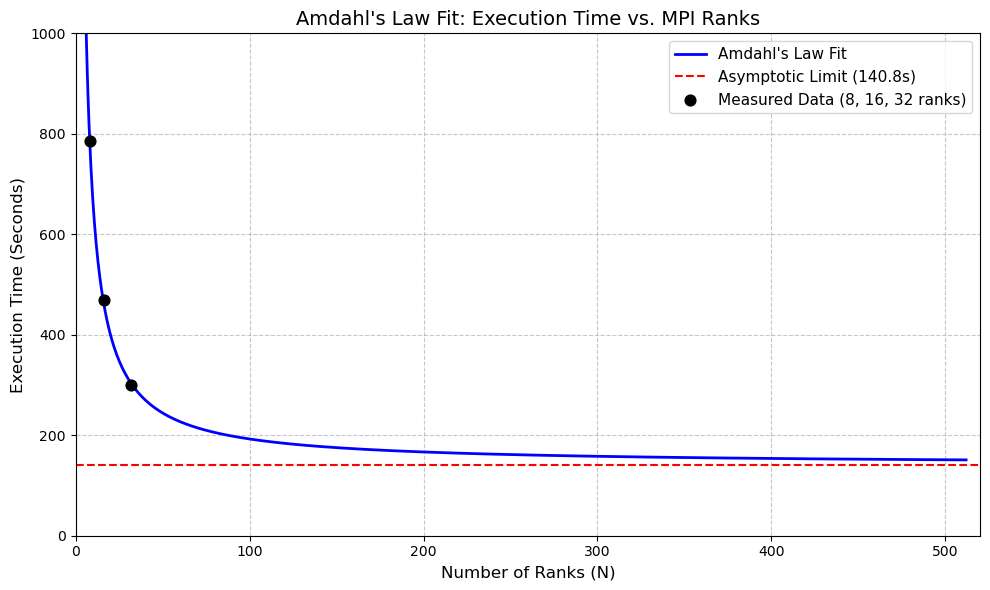

In [4]:
# 5. Plotting
plt.figure(figsize=(10, 6))

# Plot the fitted curve
plt.plot(N_plot, T_plot, 'b-', label='Amdahl\'s Law Fit', linewidth=2)

# Plot the asymptotic limit
plt.axhline(y=asymptotic_limit, color='r', linestyle='--', 
            label=f'Asymptotic Limit ({asymptotic_limit:.1f}s)')

# Plot the original data points
plt.scatter(N_data, T_data, color='black', s=60, zorder=5, label='Measured Data (8, 16, 32 ranks)')

# Annotations and styling
plt.title("Amdahl's Law Fit: Execution Time vs. MPI Ranks", fontsize=14)
plt.xlabel("Number of Ranks (N)", fontsize=12)
plt.ylabel("Execution Time (Seconds)", fontsize=12)
plt.xlim(0, 520)
plt.ylim(0, T1_opt + 100) # Optional: Limit y-axis to focus on the lower part, or let it scale automatically

# Adjust Y-limit to zoom in on the relevant curve rather than showing T(1) if it crushes the visual scale
plt.ylim(0, 1000) 

plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()